In [1]:
# Stage 1: generate video latents and save them for later dimensionality reduction
import torch
import numpy as np
from diffusers import MotionAdapter, AnimateDiffPipeline, DDIMScheduler
import os

os.makedirs('results', exist_ok=True)

# Best effort VRAM cleanup before model load
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Loading Model...")
adapter = MotionAdapter.from_pretrained(
    "guoyww/animatediff-motion-adapter-v1-5-2",
    torch_dtype=torch.float16,
)
model_id = "emilianJR/epiCRealism"
pipe = AnimateDiffPipeline.from_pretrained(
    model_id,
    motion_adapter=adapter,
    torch_dtype=torch.float16,
)

# Strong memory optimizations to avoid OOM
pipe.enable_sequential_cpu_offload()
pipe.enable_vae_slicing()
pipe.enable_vae_tiling()
pipe.enable_attention_slicing()

pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config,
    beta_schedule="linear",
    clip_sample=False,
    timestep_spacing="linspace",
    steps_offset=1,
)
print("Model Loaded!")


def generate_and_save_latents(prompt, num_frames=16, steps=12, seed=42):
    """
    Runs AnimateDiff through pipeline.__call__ and captures latents per denoising step.
    This avoids manual UNet/scheduler tensor-shape mismatches.
    """
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU is required for this notebook.")

    generator = torch.Generator(device="cuda").manual_seed(seed)
    neg_prompt = "static, motionless, blurry, distorted, noise, grain, low quality, watermark, text"

    latent_history = []

    def on_step_end(_pipe, _step_index, _timestep, callback_kwargs):
        latents = callback_kwargs["latents"]
        latent_history.append(latents.detach().float().cpu().numpy())
        return callback_kwargs

    print(f"Generating for prompt: {prompt}")

    # Use smaller defaults first for memory safety; increase later if stable.
    output = pipe(
        prompt=prompt,
        negative_prompt=neg_prompt,
        num_frames=num_frames,
        num_inference_steps=steps,
        guidance_scale=7.5,
        generator=generator,
        output_type="latent",
        callback_on_step_end=on_step_end,
        callback_on_step_end_tensor_inputs=["latents"],
    )

    # Final latents fallback if callback is not triggered by this diffusers build.
    final_latents = None
    if hasattr(output, "frames"):
        final_latents = output.frames

    if len(latent_history) == 0 and final_latents is not None:
        latent_history = [np.array(final_latents)]

    latent_history = np.array(latent_history)
    np.save("results/latent_history.npy", latent_history)
    print(f"Latents saved to results/latent_history.npy with shape {latent_history.shape}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


PROMPT = "drone camera panning right, a tiger running fast through jungle, motion blur, 4k"
generate_and_save_latents(PROMPT)

c:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Model...


c:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 826.60it/s] 1.46s/it]
CLIPTextModel LOAD REPORT from: C:\Users\Suchit\.cache\huggingface\hub\models--emilianJR--epiCRealism\snapshots\6522cf856b8c8e14638a0aaa7bd89b1b098aed17\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 


Model Loaded!
Generating for prompt: drone camera panning right, a tiger running fast through jungle, motion blur, 4k


100%|██████████| 12/12 [01:02<00:00,  5.18s/it]

Latents saved to results/latent_history.npy with shape (12, 1, 4, 16, 64, 64)


Loading Latent History...
Applying PCA...


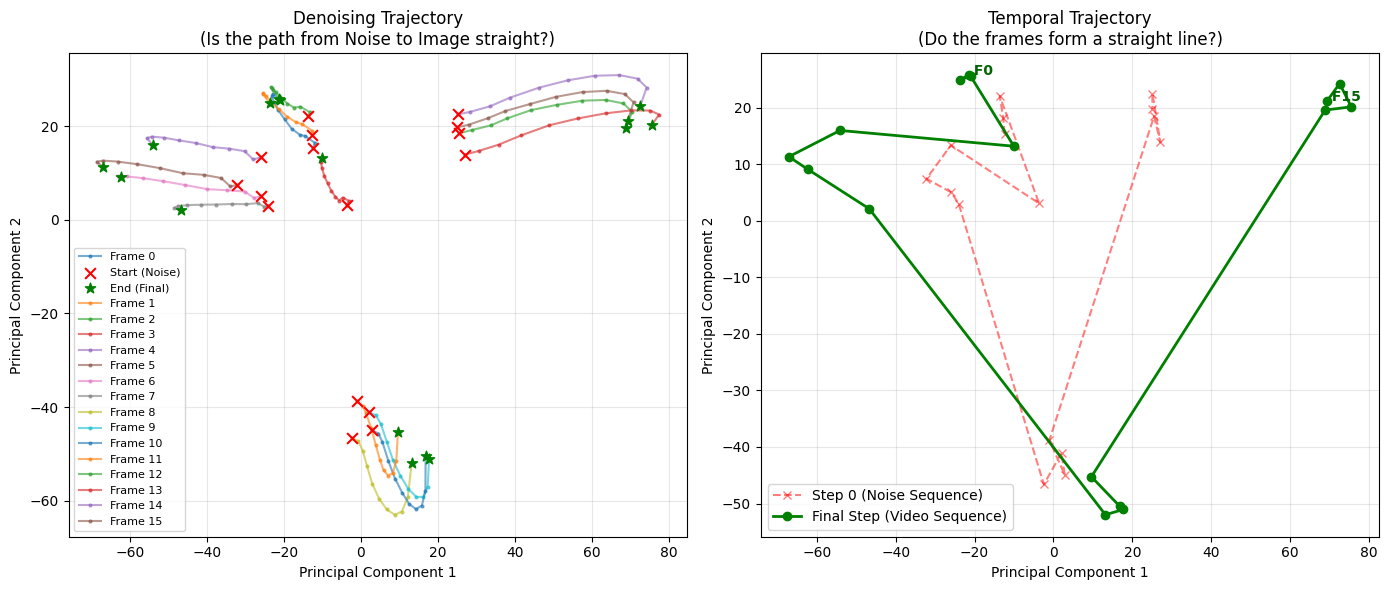


--- PERCEPTUAL STRAIGHTENING HYPOTHESIS RESULTS ---
Average Denoising Straightness: 0.6441 (Closer to 1.0 is straighter)
Temporal Straightness at Step 0 (Noise): -0.4996
Temporal Straightness at Final Step:     -0.4129
✅ HYPOTHESIS SUPPORTED: The temporal trajectory straightened out as the video resolved.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# 1. LOAD LATENTS
# ==========================================
print("Loading Latent History...")
latents = np.load("results/latent_history.npy")

# Expected shape: (steps, batch, channels, frames, height, width)
# e.g., (12, 1, 4, 8, 64, 64)
steps, batch, channels, frames, h, w = latents.shape

# Flatten the spatial and channel dimensions for each frame
# We treat each frame at each step as a single point in high-dimensional space
features = channels * h * w
latents_reshaped = latents.reshape(steps, frames, features)

# ==========================================
# 2. DIMENSIONALITY REDUCTION (PCA)
# ==========================================
# Flatten everything to fit PCA: (steps * frames, features)
flat_latents = latents_reshaped.reshape(steps * frames, features)

print("Applying PCA...")
pca = PCA(n_components=2)
latents_pca = pca.fit_transform(flat_latents)

# Reshape back to (steps, frames, 2) for easy plotting
latents_pca = latents_pca.reshape(steps, frames, 2)

# ==========================================
# 3. PLOTTING TRAJECTORIES
# ==========================================
plt.figure(figsize=(14, 6))

# --- PLOT A: The Denoising Trajectory ---
# How does each frame move from Noise to Final Image?
plt.subplot(1, 2, 1)
for f in range(frames):
    x = latents_pca[:, f, 0]
    y = latents_pca[:, f, 1]
    
    # Plot path
    plt.plot(x, y, marker='.', markersize=4, alpha=0.6, label=f'Frame {f}')
    
    # Mark Start (Noise) and End (Image)
    if f == 0: # Only add legend labels once
        plt.scatter(x[0], y[0], c='red', s=60, marker='x', label='Start (Noise)', zorder=5)
        plt.scatter(x[-1], y[-1], c='green', s=60, marker='*', label='End (Final)', zorder=5)
    else:
        plt.scatter(x[0], y[0], c='red', s=60, marker='x', zorder=5)
        plt.scatter(x[-1], y[-1], c='green', s=60, marker='*', zorder=5)

plt.title("Denoising Trajectory\n(Is the path from Noise to Image straight?)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# --- PLOT B: The Temporal Trajectory ---
# How do the frames connect to each other sequentially?
plt.subplot(1, 2, 2)

# Plot Step 0 (Pure Noise Sequence)
plt.plot(latents_pca[0, :, 0], latents_pca[0, :, 1], 
         marker='x', linestyle='--', color='red', alpha=0.5, label='Step 0 (Noise Sequence)')

# Plot Final Step (Finished Video Sequence)
plt.plot(latents_pca[-1, :, 0], latents_pca[-1, :, 1], 
         marker='o', linestyle='-', color='green', linewidth=2, label=f'Final Step (Video Sequence)')

# Annotate Frame 0 and Frame N to show direction
plt.text(latents_pca[-1, 0, 0], latents_pca[-1, 0, 1], ' F0', color='darkgreen', weight='bold')
plt.text(latents_pca[-1, -1, 0], latents_pca[-1, -1, 1], f' F{frames-1}', color='darkgreen', weight='bold')

plt.title("Temporal Trajectory\n(Do the frames form a straight line?)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/perceptual_straightening.png", dpi=150)
plt.show()

# ==========================================
# 4. MATHEMATICAL MEASUREMENT
# ==========================================
def calculate_straightness(trajectory):
    """
    Measures curvature using Cosine Similarity of consecutive steps.
    Score = 1.0 (Perfectly Straight Line)
    Score = 0.0 (90-degree turns everywhere)
    Score = -1.0 (U-turns)
    """
    if len(trajectory) < 3: 
        return 0.0
    
    # Calculate vectors between consecutive points (v_t = x_t - x_{t-1})
    deltas = trajectory[1:] - trajectory[:-1]
    
    # Normalize the vectors
    norms = np.linalg.norm(deltas, axis=1, keepdims=True)
    deltas_norm = deltas / (norms + 1e-8)
    
    # Cosine similarity between v_t and v_{t+1}
    cos_sims = np.sum(deltas_norm[:-1] * deltas_norm[1:], axis=1)
    return np.mean(cos_sims)

print("\n--- PERCEPTUAL STRAIGHTENING HYPOTHESIS RESULTS ---")

# 1. Denoising Straightness
denoise_scores = [calculate_straightness(latents_reshaped[:, f, :]) for f in range(frames)]
print(f"Average Denoising Straightness: {np.mean(denoise_scores):.4f} (Closer to 1.0 is straighter)")

# 2. Temporal Straightness
straightness_noise = calculate_straightness(latents_reshaped[0])
straightness_final = calculate_straightness(latents_reshaped[-1])

print(f"Temporal Straightness at Step 0 (Noise): {straightness_noise:.4f}")
print(f"Temporal Straightness at Final Step:     {straightness_final:.4f}")

if straightness_final > straightness_noise:
    print("✅ HYPOTHESIS SUPPORTED: The temporal trajectory straightened out as the video resolved.")
else:
    print("❌ HYPOTHESIS FAILED: The temporal trajectory became more entangled/curved.")

Loading latents...
Original shape: (12, 1, 4, 16, 64, 64)
Running PCA...

--- PERCEPTUAL STRAIGHTENING RESULTS ---
Straightness of Frame Motion at Noise Step (t=T):  -0.1718
Straightness of Frame Motion at Final Step (t=0):  0.0989


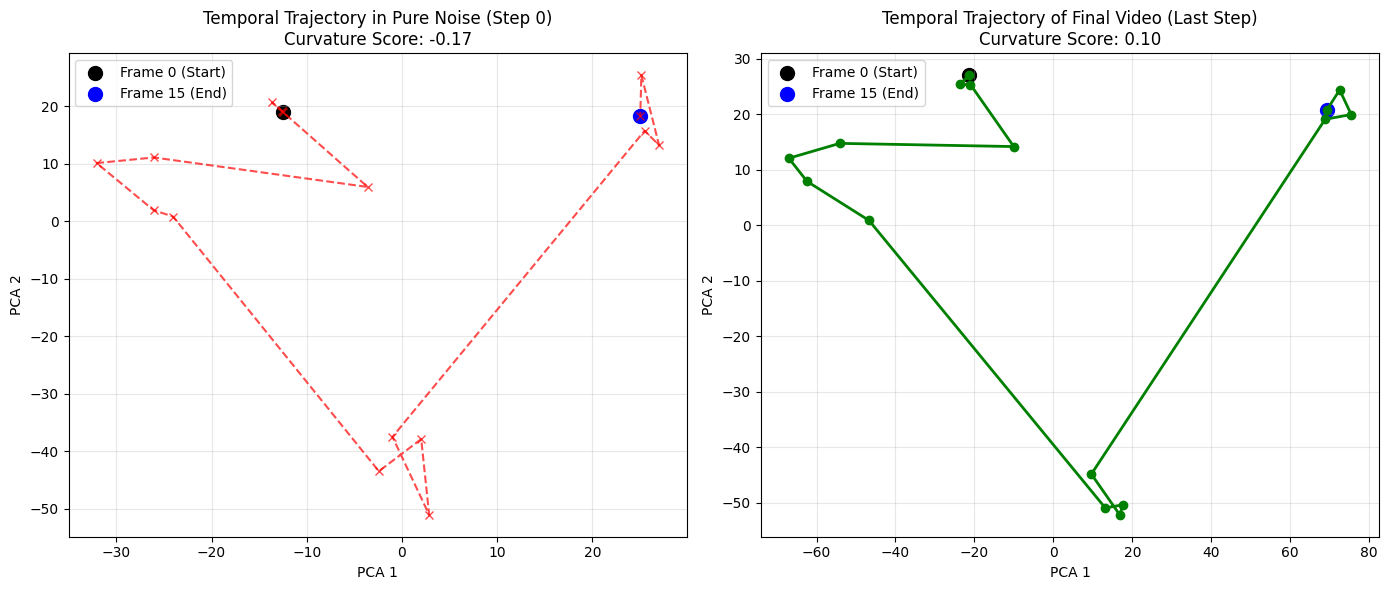

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Loading latents...")
try:
    # 1. Load Latents
    latent_history = np.load("results/latent_history.npy", allow_pickle=True)

    # Handle object arrays if fallback was used
    if latent_history.dtype == object:
        latent_history = np.array([np.array(x) for x in latent_history])

    print(f"Original shape: {latent_history.shape}")
    
    # Extract dimensions (Assuming shape: [Steps, Batch, Channels, Frames, Height, Width])
    if len(latent_history.shape) == 6:
        steps, batch, channels, frames, h, w = latent_history.shape
    elif len(latent_history.shape) == 5: # If batch was squeezed out
        steps, channels, frames, h, w = latent_history.shape
    else:
        raise ValueError(f"Unexpected shape: {latent_history.shape}")

    # 2. Reshape: Isolate frames
    # We want each frame to be a single vector of size (channels * height * width)
    features_per_frame = channels * h * w
    
    # Reshape to (steps, frames, features)
    latents_per_frame = latent_history.reshape(steps, frames, features_per_frame)

    # 3. Flatten for PCA: (steps * frames, features)
    # We fit all frames from all steps together so they share the same 2D coordinate system
    latents_flat = latents_per_frame.reshape(steps * frames, features_per_frame)

    print("Running PCA...")
    pca = PCA(n_components=2)
    pca_result_flat = pca.fit_transform(latents_flat)

    # 4. Reshape back to (steps, frames, 2) for easy plotting
    pca_result = pca_result_flat.reshape(steps, frames, 2)

    # ==========================================
    # 5. MATHEMATICAL MEASUREMENT (Cosine Similarity)
    # ==========================================
    def calculate_straightness(trajectory):
        """Measures how straight a sequence of points is (1.0 = perfect straight line)."""
        if len(trajectory) < 3: return 0.0
        deltas = trajectory[1:] - trajectory[:-1] # Vectors between frames
        norms = np.linalg.norm(deltas, axis=1, keepdims=True)
        deltas_norm = deltas / (norms + 1e-8)
        cos_sims = np.sum(deltas_norm[:-1] * deltas_norm[1:], axis=1)
        return np.mean(cos_sims)

    straightness_noise = calculate_straightness(pca_result[0])
    straightness_final = calculate_straightness(pca_result[-1])

    print("\n--- PERCEPTUAL STRAIGHTENING RESULTS ---")
    print(f"Straightness of Frame Motion at Noise Step (t=T):  {straightness_noise:.4f}")
    print(f"Straightness of Frame Motion at Final Step (t=0):  {straightness_final:.4f}")

    # ==========================================
    # 6. PLOTTING
    # ==========================================
    plt.figure(figsize=(14, 6))

    # Plot A: Frame trajectory when it is pure noise (Step 0)
    plt.subplot(1, 2, 1)
    noise_traj = pca_result[0] # First step
    plt.plot(noise_traj[:, 0], noise_traj[:, 1], marker='x', linestyle='--', color='red', alpha=0.7)
    plt.scatter(noise_traj[0, 0], noise_traj[0, 1], color='black', s=100, label="Frame 0 (Start)")
    plt.scatter(noise_traj[-1, 0], noise_traj[-1, 1], color='blue', s=100, label=f"Frame {frames-1} (End)")
    
    plt.title(f"Temporal Trajectory in Pure Noise (Step 0)\nCurvature Score: {straightness_noise:.2f}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot B: Frame trajectory in the final video (Last Step)
    plt.subplot(1, 2, 2)
    final_traj = pca_result[-1] # Last step
    plt.plot(final_traj[:, 0], final_traj[:, 1], marker='o', linestyle='-', color='green', linewidth=2)
    plt.scatter(final_traj[0, 0], final_traj[0, 1], color='black', s=100, label="Frame 0 (Start)")
    plt.scatter(final_traj[-1, 0], final_traj[-1, 1], color='blue', s=100, label=f"Frame {frames-1} (End)")
    
    plt.title(f"Temporal Trajectory of Final Video (Last Step)\nCurvature Score: {straightness_final:.2f}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: results/latent_history.npy not found.")
except Exception as e:
    print(f"Error while reducing latents: {e}")

# Generating for all methods

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import math
import cv2
import os
from PIL import Image
from diffusers import MotionAdapter, AnimateDiffPipeline, DDIMScheduler
from diffusers.utils import export_to_gif
from tqdm import tqdm

os.makedirs('results', exist_ok=True)

# Best effort VRAM cleanup
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ==========================================
# 1. LOAD MODEL
# ==========================================
print("Loading Model...")
adapter = MotionAdapter.from_pretrained("guoyww/animatediff-motion-adapter-v1-5-2", torch_dtype=torch.float16)
model_id = "emilianJR/epiCRealism"
pipe = AnimateDiffPipeline.from_pretrained(model_id, motion_adapter=adapter, torch_dtype=torch.float16)
pipe.to("cuda")

# Memory Optimization
pipe.enable_sequential_cpu_offload()
pipe.enable_vae_slicing()
pipe.enable_vae_tiling()
pipe.enable_attention_slicing()

pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config,
    beta_schedule="linear",
    clip_sample=False,
    timestep_spacing="linspace",
    steps_offset=1
)
print("✅ Model Loaded!")


# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def tensor_to_pil(video_tensor):
    if video_tensor.ndim == 5: video_tensor = video_tensor[0]
    video_tensor = video_tensor.permute(1, 2, 3, 0).cpu() # [F, H, W, C]
    video_np = (video_tensor.float().numpy() * 255).clip(0, 255).astype(np.uint8)
    return [Image.fromarray(f) for f in video_np]


# ==========================================
# 3. RLC CONSTRAINT METHODS
# ==========================================

def apply_phase2_rlc(noise_pred, latents, **kwargs):
    """Phase 2: Frozen World Era (Latent-Based Smoothing translated to Noise Update)"""
    latents_padded = F.pad(latents, (0,0, 0,0, 1,1), mode="replicate")
    latents_smooth = (latents_padded[:, :, :-2] + latents_padded[:, :, 1:-1] + latents_padded[:, :, 2:]) / 3.0
    error_vector = latents_smooth - latents
    
    # Safe Normalization
    noise_mag = noise_pred.std()
    error_mag = error_vector.std()
    
    # Scale correction so it never exceeds 15% of noise magnitude
    scale = min(1.0, (noise_mag / error_mag) * 0.15) if error_mag > 1e-6 else 0
    scaled_correction = error_vector * scale
    
    final_noise = noise_pred - scaled_correction
    return final_noise


def apply_phase4_gradient_rlc(noise_pred, step_idx, total_steps, **kwargs):
    """Phase 4: Gradient Consensus Era (Direct Noise Smoothing with scheduling)"""
    progress = step_idx / total_steps
    
    # Shut off constraint in the final 20% of steps
    if progress < 0.8:
        original_std = noise_pred.std()
        n_padded = F.pad(noise_pred, (0,0, 0,0, 1,1), mode="replicate")
        n_smooth = (n_padded[:,:,:-2] + 2*n_padded[:,:,1:-1] + n_padded[:,:,2:]) / 4.0
        
        final_noise = noise_pred + 0.3 * (n_smooth - noise_pred)
        new_std = final_noise.std()
        
        if new_std > 1e-6:
            final_noise = final_noise * (original_std / new_std)
        return final_noise
        
    return noise_pred


def apply_phase5_anomaly_rlc(noise_pred, step_idx, total_steps, **kwargs):
    """Phase 5: Anomaly-Based Selective Smoothing"""
    progress = step_idx / total_steps
    out_dtype = noise_pred.dtype
    
    if progress < 0.4 or progress > 0.9:
        return noise_pred
        
    window_progress = (progress - 0.4) / 0.5
    strength = 0.1 * (0.5 * (1 + math.cos(math.pi * window_progress)))
    
    if strength < 1e-6: return noise_pred
    
    temporal_diff = torch.abs(noise_pred[:, :, 1:] - noise_pred[:, :, :-1])
    diff_magnitude = temporal_diff.mean(dim=1, keepdim=True)
    median_diff = diff_magnitude.median()
    threshold = 2.0 * median_diff
    
    anomaly_mask_partial = (diff_magnitude > threshold).float()
    anomaly_mask = torch.cat([anomaly_mask_partial[:, :, :1], anomaly_mask_partial], dim=2)
    
    n_padded = F.pad(noise_pred, (0,0, 0,0, 1,1), mode="replicate")
    n_smooth = (n_padded[:,:,:-2] + 2*n_padded[:,:,1:-1] + n_padded[:,:,2:]) / 4.0
    
    blend_mask = anomaly_mask * strength
    final_noise = noise_pred + blend_mask * (n_smooth - noise_pred)
    
    return final_noise.to(dtype=out_dtype)


# ==========================================
# 4. CUSTOM GENERATION LOOP (Saves Latents)
# ==========================================
@torch.no_grad()
def generate_and_save(prompt, method_name, rlc_fn=None, num_frames=16, steps=20, seed=42):
    print(f"\n--- Generating: {method_name} ---")
    generator = torch.Generator(device="cuda").manual_seed(seed)
    
    neg_prompt = "static, motionless, blurry, distorted, noise, grain, low quality, watermark, text"
    prompt_embeds, negative_embeds = pipe.encode_prompt(
        prompt, device="cuda", num_images_per_prompt=1, do_classifier_free_guidance=True,
        negative_prompt=neg_prompt
    )
    batch_embeds = torch.cat([negative_embeds, prompt_embeds]).repeat_interleave(num_frames, dim=0)
    
    # Init Latents
    latents = torch.randn((1, 4, num_frames, 64, 64), device="cuda", dtype=torch.float16, generator=generator)
    pipe.scheduler.set_timesteps(steps)
    
    latent_history = []
    # Save the initial pure noise state (Step 0)
    latent_history.append(latents.detach().float().cpu().numpy())
    
    # Denoising Loop with tqdm
    for i, t in enumerate(tqdm(pipe.scheduler.timesteps, desc=f"Steps for {method_name}")):
        latent_input = torch.cat([latents] * 2)
        latent_input = pipe.scheduler.scale_model_input(latent_input, t)
        
        noise_pred = pipe.unet(latent_input, t, encoder_hidden_states=batch_embeds).sample
        noise_uncond, noise_text = noise_pred.chunk(2)
        noise_pred = noise_uncond + 7.5 * (noise_text - noise_uncond)
        
        # Apply the chosen Constraint
        if rlc_fn is not None:
            noise_pred = rlc_fn(noise_pred=noise_pred, latents=latents, t=t, step_idx=i, total_steps=steps)
            
        # Step the Scheduler
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
        
        # Save the latent state after every step
        latent_history.append(latents.detach().float().cpu().numpy())
        
    # Decode Video
    print("Decoding latents to video...")
    decode_latents = 1 / 0.18215 * latents
    latents_2d = decode_latents.permute(0, 2, 1, 3, 4).flatten(0, 1)
    video = pipe.vae.decode(latents_2d).sample
    video = video.reshape(1, num_frames, 3, 512, 512)
    video = video.permute(0, 2, 1, 3, 4)
    
    # Save Video
    gif_path = f"results/video_{method_name}.gif"
    export_to_gif(tensor_to_pil(video), gif_path)
    print(f"✅ Saved Video: {gif_path}")
    
    # Save Latents
    latent_history_np = np.array(latent_history)
    save_path = f"results/latents_{method_name}.npy"
    np.save(save_path, latent_history_np)
    print(f"✅ Saved Latents: {save_path} (Shape: {latent_history_np.shape})")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ==========================================
# 5. EXECUTE ALL EXPERIMENTS
# ==========================================
PROMPT = "drone camera panning right, a tiger running fast through jungle, motion blur, 4k"
SEED = 999
FRAMES = 16
STEPS = 20 # Increased slightly to match your phase math assumptions

# Run 1: Baseline
generate_and_save(PROMPT, method_name="baseline", rlc_fn=None, num_frames=FRAMES, steps=STEPS, seed=SEED)

# Run 2: Phase 2
generate_and_save(PROMPT, method_name="phase2", rlc_fn=apply_phase2_rlc, num_frames=FRAMES, steps=STEPS, seed=SEED)

# Run 3: Phase 4
generate_and_save(PROMPT, method_name="phase4", rlc_fn=apply_phase4_gradient_rlc, num_frames=FRAMES, steps=STEPS, seed=SEED)

# Run 4: Phase 5
generate_and_save(PROMPT, method_name="phase5", rlc_fn=apply_phase5_anomaly_rlc, num_frames=FRAMES, steps=STEPS, seed=SEED)

print("\n🎉 ALL GENERATIONS COMPLETE! All latents saved in /results/")

Loading Model...


c:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 540.38it/s] 1.89s/it]
CLIPTextModel LOAD REPORT from: C:\Users\Suchit\.cache\huggingface\hub\models--emilianJR--epiCRealism\snapshots\6522cf856b8c8e14638a0aaa7bd89b1b098aed17\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 


✅ Model Loaded!

--- Generating: baseline ---


Steps for baseline: 100%|██████████| 20/20 [01:34<00:00,  4.72s/it]


Decoding latents to video...
✅ Saved Video: results/video_baseline.gif
✅ Saved Latents: results/latents_baseline.npy (Shape: (21, 1, 4, 16, 64, 64))

--- Generating: phase2 ---


...

Decoding latents to video...
✅ Saved Video: results/video_phase2.gif
✅ Saved Latents: results/latents_phase2.npy (Shape: (21, 1, 4, 16, 64, 64))

--- Generating: phase4 ---


Steps for phase4: 100%|██████████| 20/20 [01:35<00:00,  4.76s/it]


Decoding latents to video...
✅ Saved Video: results/video_phase4.gif
✅ Saved Latents: results/latents_phase4.npy (Shape: (21, 1, 4, 16, 64, 64))

--- Generating: phase5 ---


Steps for phase5: 100%|██████████| 20/20 [01:33<00:00,  4.67s/it]


Decoding latents to video...
✅ Saved Video: results/video_phase5.gif
✅ Saved Latents: results/latents_phase5.npy (Shape: (21, 1, 4, 16, 64, 64))

🎉 ALL GENERATIONS COMPLETE! All latents saved in /results/


Loading latents...
Found 4 latent files.

=== Processing: baseline ===
Original shape: (21, 1, 4, 16, 64, 64)
Running PCA...
--- PERCEPTUAL STRAIGHTENING RESULTS ---
Straightness of Frame Motion at Noise Step (t=T):  -0.1294
Straightness of Frame Motion at Final Step (t=0):  -0.0048


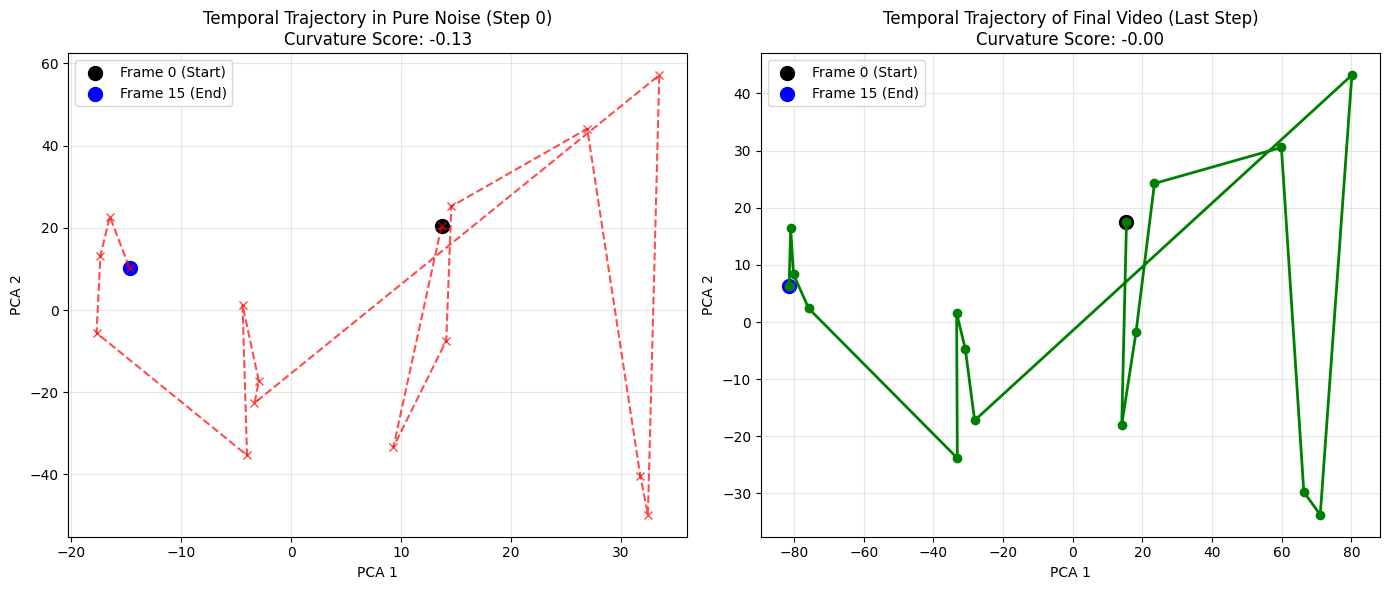

Saved: results/trajectory/trajectory_baseline.png

=== Processing: phase2 ===
Original shape: (21, 1, 4, 16, 64, 64)
Running PCA...
--- PERCEPTUAL STRAIGHTENING RESULTS ---
Straightness of Frame Motion at Noise Step (t=T):  -0.4352
Straightness of Frame Motion at Final Step (t=0):  0.1911


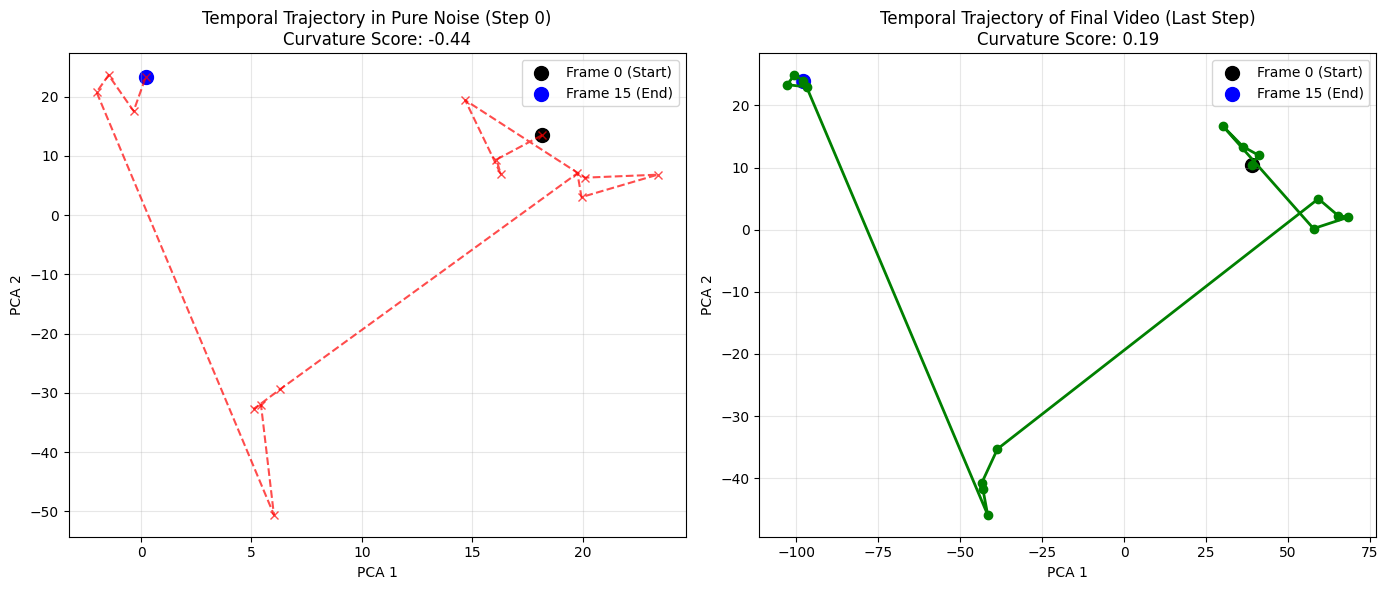

Saved: results/trajectory/trajectory_phase2.png

=== Processing: phase4 ===
Original shape: (21, 1, 4, 16, 64, 64)
Running PCA...
--- PERCEPTUAL STRAIGHTENING RESULTS ---
Straightness of Frame Motion at Noise Step (t=T):  -0.0891
Straightness of Frame Motion at Final Step (t=0):  -0.0147


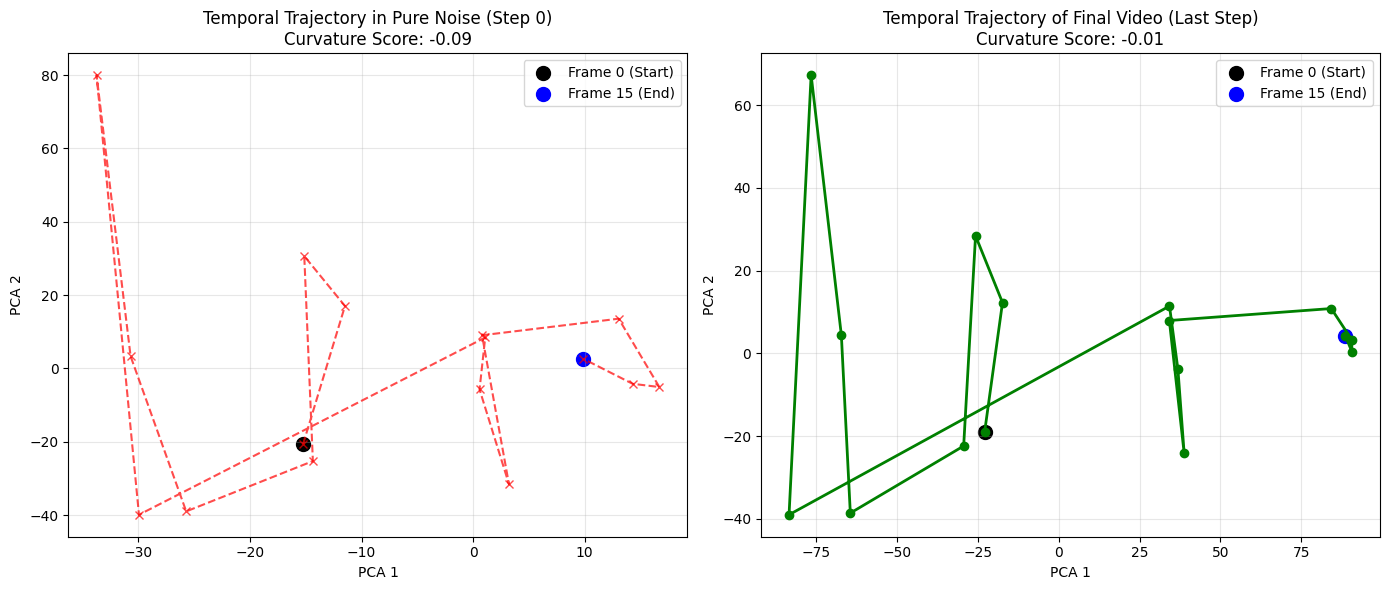

Saved: results/trajectory/trajectory_phase4.png

=== Processing: phase5 ===
Original shape: (21, 1, 4, 16, 64, 64)
Running PCA...
--- PERCEPTUAL STRAIGHTENING RESULTS ---
Straightness of Frame Motion at Noise Step (t=T):  0.1311
Straightness of Frame Motion at Final Step (t=0):  0.2433


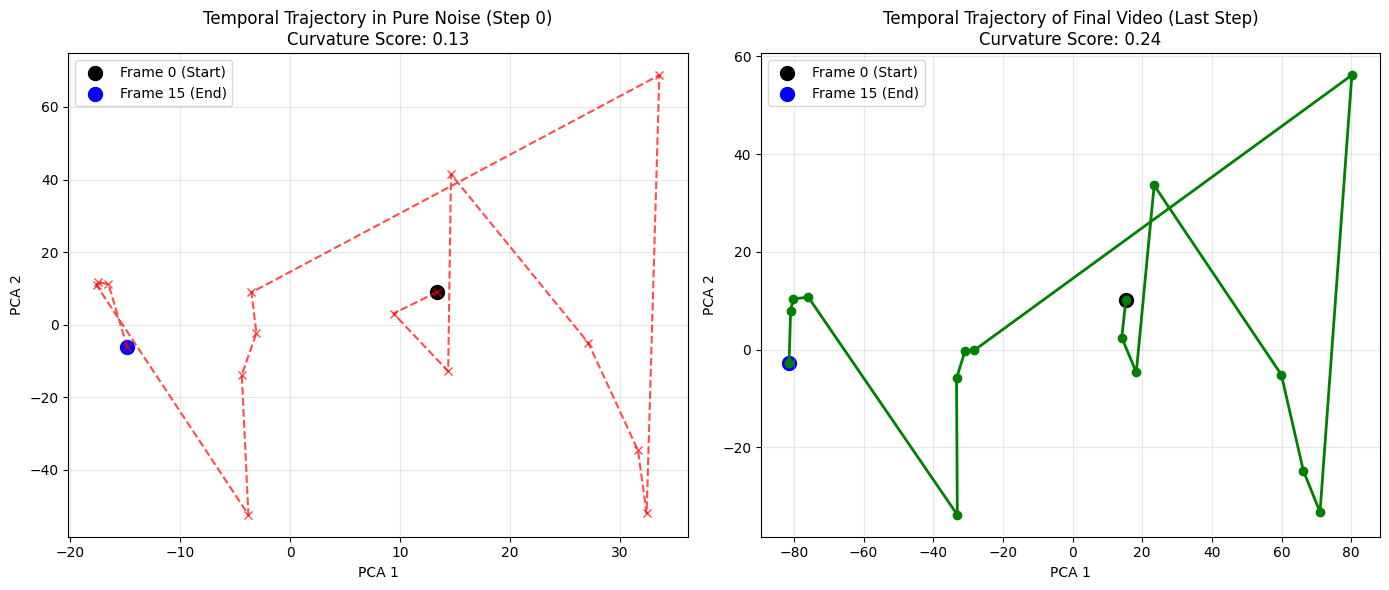

Saved: results/trajectory/trajectory_phase5.png


In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Loading latents...")
os.makedirs("results/trajectory", exist_ok=True)

# Collect all method latents produced by the generation cell.
# Example files: latents_baseline.npy, latents_phase2.npy, latents_phase4.npy, latents_phase5.npy
latent_files = sorted(glob.glob("results/latents_*.npy"))

if not latent_files:
    print("No files matched results/latents_*.npy")
else:
    print(f"Found {len(latent_files)} latent files.")

def calculate_straightness(trajectory):
    """Measures how straight a sequence of points is (1.0 = perfect straight line)."""
    if len(trajectory) < 3:
        return 0.0
    deltas = trajectory[1:] - trajectory[:-1]  # Vectors between frames
    norms = np.linalg.norm(deltas, axis=1, keepdims=True)
    deltas_norm = deltas / (norms + 1e-8)
    cos_sims = np.sum(deltas_norm[:-1] * deltas_norm[1:], axis=1)
    return float(np.mean(cos_sims))

for latent_path in latent_files:
    method_name = os.path.splitext(os.path.basename(latent_path))[0].replace("latents_", "")
    print(f"\n=== Processing: {method_name} ===")

    try:
        # 1. Load Latents
        latent_history = np.load(latent_path, allow_pickle=True)

        # Handle object arrays if fallback was used
        if latent_history.dtype == object:
            latent_history = np.array([np.array(x) for x in latent_history])

        print(f"Original shape: {latent_history.shape}")

        # Extract dimensions (expected shapes: [steps,batch,channels,frames,h,w] or [steps,channels,frames,h,w])
        if len(latent_history.shape) == 6:
            steps, batch, channels, frames, h, w = latent_history.shape
            if batch > 1:
                print(f"Warning: batch={batch}. Using batch index 0 for plotting.")
            latent_history = latent_history[:, 0]  # Use first batch item to keep plot comparable
            steps, channels, frames, h, w = latent_history.shape
        elif len(latent_history.shape) == 5:
            steps, channels, frames, h, w = latent_history.shape
        else:
            raise ValueError(f"Unexpected shape: {latent_history.shape}")

        # 2. Reshape: Isolate frames
        # We want each frame to be a single vector of size (channels * height * width)
        features_per_frame = channels * h * w

        # Reshape to (steps, frames, features)
        latents_per_frame = latent_history.reshape(steps, frames, features_per_frame)

        # 3. Flatten for PCA: (steps * frames, features)
        # We fit all frames from all steps together so they share the same 2D coordinate system
        latents_flat = latents_per_frame.reshape(steps * frames, features_per_frame)

        print("Running PCA...")
        pca = PCA(n_components=2)
        pca_result_flat = pca.fit_transform(latents_flat)

        # 4. Reshape back to (steps, frames, 2) for easy plotting
        pca_result = pca_result_flat.reshape(steps, frames, 2)

        # 5. Mathematical measurement (Cosine Similarity)
        straightness_noise = calculate_straightness(pca_result[0])
        straightness_final = calculate_straightness(pca_result[-1])

        print("--- PERCEPTUAL STRAIGHTENING RESULTS ---")
        print(f"Straightness of Frame Motion at Noise Step (t=T):  {straightness_noise:.4f}")
        print(f"Straightness of Frame Motion at Final Step (t=0):  {straightness_final:.4f}")

        # 6. Plotting (same style as original)
        plt.figure(figsize=(14, 6))

        # Plot A: Frame trajectory when it is pure noise (Step 0)
        plt.subplot(1, 2, 1)
        noise_traj = pca_result[0]  # First step
        plt.plot(noise_traj[:, 0], noise_traj[:, 1], marker='x', linestyle='--', color='red', alpha=0.7)
        plt.scatter(noise_traj[0, 0], noise_traj[0, 1], color='black', s=100, label="Frame 0 (Start)")
        plt.scatter(noise_traj[-1, 0], noise_traj[-1, 1], color='blue', s=100, label=f"Frame {frames-1} (End)")

        plt.title(f"Temporal Trajectory in Pure Noise (Step 0)\nCurvature Score: {straightness_noise:.2f}")
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot B: Frame trajectory in the final video (Last Step)
        plt.subplot(1, 2, 2)
        final_traj = pca_result[-1]  # Last step
        plt.plot(final_traj[:, 0], final_traj[:, 1], marker='o', linestyle='-', color='green', linewidth=2)
        plt.scatter(final_traj[0, 0], final_traj[0, 1], color='black', s=100, label="Frame 0 (Start)")
        plt.scatter(final_traj[-1, 0], final_traj[-1, 1], color='blue', s=100, label=f"Frame {frames-1} (End)")

        plt.title(f"Temporal Trajectory of Final Video (Last Step)\nCurvature Score: {straightness_final:.2f}")
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()

        out_path = f"results/trajectory/trajectory_{method_name}.png"
        plt.savefig(out_path, dpi=150)
        plt.show()
        plt.close()
        print(f"Saved: {out_path}")

    except FileNotFoundError:
        print(f"Error: {latent_path} not found.")
    except Exception as e:
        print(f"Error while reducing latents for {method_name}: {e}")